# S&P 500 Credit Health Analysis

> **Research Question**: Which S&P 500 companies are financially deteriorating, and can a data-driven scoring model identify them systematically?

This notebook builds an end-to-end credit health scoring pipeline for 389 S&P 500 companies across 9 sectors, covering fiscal years 2022-2025.

**Pipeline Overview**
```
Extract       yfinance API - financial statements (2022-2025)
              GitHub CSV   - S&P 500 constituent list + GICS sectors
    |
Transform     CAGR-based interest expense imputation
              Winsorization of outliers
              6 credit health metrics calculated
    |
Score         Within-sector percentile ranking
              Weighted scoring model (6 metrics)
              Letter rating assignment (AAA to CCC)
    |
Visualize     Rating distribution
              Sector trends
              Risk watchlist
```

**Skills demonstrated**: ETL pipeline, API integration, data cleaning, Winsorization, CAGR imputation, percentile ranking, weighted scoring, financial analysis

---
## 0. Setup

In [1]:
import json
import os
import time
import warnings

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import requests
import yfinance as yf

warnings.filterwarnings('ignore')
pd.reset_option('display.float_format')

os.makedirs('data', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# File paths
RAW_FILE   = 'data/sp500_raw.csv'
CLEAN_FILE = 'data/sp500_clean.csv'
SCORE_FILE = 'data/sp500_scores.csv'

print('Setup complete.')

Setup complete.


---
## 1. Load S&P 500 Constituent List

We pull the current S&P 500 list from a public GitHub source maintained alongside the index.
Each company has a GICS (Global Industry Classification Standard) sector label.

**Why exclude Financials and Real Estate?**
- Banks use interest income as revenue - EBITDA and FCF metrics are not meaningful
- REITs use FFO (Funds From Operations) instead of FCF as their core cash flow metric
- Applying our 6 metrics to these sectors would produce misleading scores

In [2]:
url = 'https://raw.githubusercontent.com/datasets/s-and-p-500-companies/main/data/constituents.csv'
sp500 = pd.read_csv(url)

print(f'Total S&P 500 companies: {len(sp500)}')
print('\nSector distribution (before filtering):')
print(sp500['GICS Sector'].value_counts())

Total S&P 500 companies: 503

Sector distribution (before filtering):
GICS Sector
Industrials               80
Financials                76
Information Technology    74
Health Care               59
Consumer Discretionary    47
Consumer Staples          35
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    21
Name: count, dtype: int64


In [3]:
# Remove sectors where our credit metrics are not applicable
exclude_sectors = ['Financials', 'Real Estate']
sp500_filtered  = sp500[~sp500['GICS Sector'].isin(exclude_sectors)].reset_index(drop=True)

print(f'Companies after filtering: {len(sp500_filtered)}')
print('\nRemaining sectors:')
print(sp500_filtered['GICS Sector'].value_counts())

Companies after filtering: 396

Remaining sectors:
GICS Sector
Industrials               80
Information Technology    74
Health Care               59
Consumer Discretionary    47
Consumer Staples          35
Utilities                 31
Materials                 26
Communication Services    23
Energy                    21
Name: count, dtype: int64


---
## 2. Extract - Pull Financial Statements from yfinance

For each company we pull three financial statements:
- **Income Statement**: revenue, EBITDA, EBIT, interest expense
- **Balance Sheet**: current assets/liabilities, total liabilities, equity
- **Cash Flow Statement**: free cash flow

**Interest expense handling**: yfinance sometimes stores interest expense under different field names across years. We try three sources in order:
1. `Interest Expense Non Operating`
2. `Interest Expense` (fallback)
3. `Interest Paid Supplemental Data` from cash flow (second fallback)

In [4]:
def extract_single_company(ticker_symbol):
    """
    Extract 9 key financial fields for one company.
    Returns a DataFrame with one row per fiscal year, or None on failure.
    """
    try:
        ticker   = yf.Ticker(ticker_symbol)
        income   = ticker.financials
        balance  = ticker.balance_sheet
        cashflow = ticker.cashflow

        def get_field(statement, field_name):
            """Safely extract one row; return NaN series if field missing."""
            if field_name in statement.index:
                return statement.loc[field_name]
            return pd.Series(np.nan, index=statement.columns)

        # --- Income Statement ---
        revenue = get_field(income, 'Total Revenue')
        ebitda  = get_field(income, 'EBITDA')
        ebit    = get_field(income, 'EBIT')

        # Interest expense: try three sources in order
        interest = get_field(income, 'Interest Expense Non Operating')
        if interest.isna().all():
            interest = get_field(income, 'Interest Expense')
        if interest.isna().all():
            interest = get_field(cashflow, 'Interest Paid Supplemental Data')

        # --- Balance Sheet ---
        current_assets = get_field(balance, 'Current Assets')
        current_liab   = get_field(balance, 'Current Liabilities')
        total_liab     = get_field(balance, 'Total Liabilities Net Minority Interest')
        equity         = get_field(balance, 'Stockholders Equity')

        # --- Cash Flow ---
        fcf = get_field(cashflow, 'Free Cash Flow')

        df = pd.DataFrame({
            'ticker'          : ticker_symbol,
            'revenue'         : revenue,
            'ebitda'          : ebitda,
            'ebit'            : ebit,
            'interest_expense': interest,
            'current_assets'  : current_assets,
            'current_liab'    : current_liab,
            'total_liab'      : total_liab,
            'equity'          : equity,
            'fcf'             : fcf,
        })

        df.index.name = 'fiscal_year'
        df = df.reset_index()
        df['fiscal_year'] = pd.to_datetime(df['fiscal_year']).dt.year
        return df

    except Exception as e:
        print(f'Error extracting {ticker_symbol}: {e}')
        return None

---
## 3. Transform - Clean and Impute Missing Data

### Interest Expense Imputation

Some companies have missing interest expense for recent years (yfinance data gap).
We use a CAGR-based projection rather than simple forward fill because:
- Simple forward fill assumes zero change, which underestimates interest for growing companies
- CAGR captures the historical trend in debt levels
- We cap CAGR at +-30% to prevent outlier distortion
- Minimum 3 valid data points required; otherwise fall back to forward fill

**Limitation**: If a company significantly restructured its debt during the gap period, this estimate will be inaccurate. This affects a small number of companies and is documented here.

In [5]:
def fill_interest(df):
    """
    Fill missing interest_expense values.
    Uses CAGR projection if 3+ valid historical values exist,
    otherwise falls back to forward fill.
    """
    df    = df.sort_values('fiscal_year').reset_index(drop=True)
    valid = df[df['interest_expense'].notna()][['fiscal_year', 'interest_expense']]

    if len(valid) >= 3:
        first_year  = valid.iloc[0]['fiscal_year']
        last_year   = valid.iloc[-1]['fiscal_year']
        first_value = valid.iloc[0]['interest_expense']
        last_value  = valid.iloc[-1]['interest_expense']
        n_years     = last_year - first_year

        # Guard against divide by zero (companies with zero historical interest)
        if first_value == 0 or n_years == 0:
            df['interest_expense'] = df['interest_expense'].fillna(method='ffill')
            return df

        cagr = (last_value / first_value) ** (1 / n_years) - 1
        cagr = min(max(cagr, -0.30), 0.30)  # Cap between -30% and +30%

        last_valid_value = last_value
        last_valid_year  = last_year

        for i, row in df[df['interest_expense'].isna()].iterrows():
            years_ahead = row['fiscal_year'] - last_valid_year
            estimated   = last_valid_value * (1 + cagr) ** years_ahead
            df.at[i, 'interest_expense'] = estimated
    else:
        # Not enough history for CAGR - use forward fill
        df['interest_expense'] = df['interest_expense'].fillna(method='ffill')

    return df


def clean_company_data(df):
    """
    Clean one company's financial data:
    1. Fill interest expense (CAGR or forward fill)
    2. Drop rows where more than 4 of 9 fields are NaN
    """
    numeric_cols = [
        'revenue', 'ebitda', 'ebit', 'interest_expense',
        'current_assets', 'current_liab', 'total_liab', 'equity', 'fcf'
    ]
    # Fill interest first, then drop incomplete rows
    # (order matters: filling before dropping preserves more CAGR history)
    df = fill_interest(df)
    df = df.dropna(subset=numeric_cols, thresh=5)
    return df

---
## 4. Load - Batch Fetch with Checkpointing

Fetching 396 companies takes approximately 6-7 minutes.
We save progress every 50 companies so the pipeline can resume if interrupted.

**If a cache already exists, this step is skipped entirely.**

In [6]:
def fetch_all_companies(tickers_df, output_file=RAW_FILE, delay=0.8):
    """
    Batch fetch financial data for all companies.
    Saves a checkpoint every 50 companies and resumes from last checkpoint
    if the output file already exists.
    """
    os.makedirs('data', exist_ok=True)

    # Resume from checkpoint if it exists
    if os.path.exists(output_file):
        existing     = pd.read_csv(output_file)
        done_tickers = existing['ticker'].unique().tolist()
        print(f'Resuming - already fetched: {len(done_tickers)} companies')
    else:
        existing     = pd.DataFrame()
        done_tickers = []

    tickers_list = tickers_df['Symbol'].tolist()
    remaining    = [t for t in tickers_list if t not in done_tickers]
    print(f'Remaining: {len(remaining)} companies')

    results = []
    failed  = []

    for i, ticker_symbol in enumerate(remaining):
        try:
            df = extract_single_company(ticker_symbol)
            if df is not None:
                df_clean = clean_company_data(df)
                sector   = tickers_df[
                    tickers_df['Symbol'] == ticker_symbol
                ]['GICS Sector'].values[0]
                df_clean['sector'] = sector

                if len(df_clean) > 0:
                    results.append(df_clean)
                    print(f'[{i+1}/{len(remaining)}] {ticker_symbol} - {len(df_clean)} rows')
                else:
                    failed.append(ticker_symbol)
        except Exception as e:
            failed.append(ticker_symbol)
            print(f'[{i+1}/{len(remaining)}] {ticker_symbol} - error: {e}')

        # Save checkpoint every 50 companies
        if (i + 1) % 50 == 0 and results:
            batch    = pd.concat(results, ignore_index=True)
            combined = pd.concat([existing, batch], ignore_index=True)
            combined.to_csv(output_file, index=False)
            existing = combined
            results  = []
            print(f'--- Checkpoint saved at {i+1} companies ---')

        time.sleep(delay)

    # Save any remaining results
    if results:
        batch    = pd.concat(results, ignore_index=True)
        combined = pd.concat([existing, batch], ignore_index=True)
        combined.to_csv(output_file, index=False)

    print(f'\nDone. Failed tickers ({len(failed)}): {failed}')
    return pd.read_csv(output_file)

In [7]:
# Run the pipeline (skips if cache already exists)
if os.path.exists(RAW_FILE):
    print(f'Cache found at {RAW_FILE} - loading directly.')
    df_raw = pd.read_csv(RAW_FILE)
else:
    print('No cache found - fetching from yfinance (~6-7 minutes)...')
    df_raw = fetch_all_companies(sp500_filtered)

print(f'\nRaw data: {len(df_raw)} rows, {df_raw["ticker"].nunique()} companies')
print(f'Years: {sorted(df_raw["fiscal_year"].unique())}')

Cache found at data/sp500_raw.csv - loading directly.

Raw data: 1578 rows, 395 companies
Years: [2021, 2022, 2023, 2024, 2025, 2026]


---
## 5. Data Quality Check

Before calculating metrics, we audit missing values and apply final cleaning rules:
- `interest_expense` NaN means no debt - fill with 0 (legitimate zero, not missing)
- Drop rows where any core metric is still missing after imputation

In [8]:
print('Missing values in raw data:')
print(df_raw.isnull().sum())

Missing values in raw data:
fiscal_year          0
ticker               0
revenue              1
ebitda              13
ebit                 5
interest_expense    41
current_assets      11
current_liab        11
total_liab          11
equity               3
fcf                  1
sector               0
dtype: int64


In [9]:
df = df_raw.copy()

# Companies with no debt legitimately have zero interest expense
df['interest_expense'] = df['interest_expense'].fillna(0)

# Drop rows where core metrics are still missing
core_fields = [
    'revenue', 'ebitda', 'ebit',
    'current_assets', 'current_liab', 'total_liab', 'equity', 'fcf'
]
df = df.dropna(subset=core_fields)

print(f'Rows after cleaning: {len(df)}')
print(f'Companies: {df["ticker"].nunique()}')
print(f'\nRemaining missing values:')
print(df.isnull().sum())

df.to_csv(CLEAN_FILE, index=False)
print(f'\nSaved to {CLEAN_FILE}')

Rows after cleaning: 1550
Companies: 389

Remaining missing values:
fiscal_year         0
ticker              0
revenue             0
ebitda              0
ebit                0
interest_expense    0
current_assets      0
current_liab        0
total_liab          0
equity              0
fcf                 0
sector              0
dtype: int64

Saved to data/sp500_clean.csv


---
## 6. Calculate Credit Health Metrics

We compute 6 metrics from the 9 raw financial fields.
Each metric captures a distinct dimension of credit health:

| Metric | Formula | Dimension |
|---|---|---|
| EBITDA Margin | EBITDA / Revenue | Profitability |
| Debt-to-Equity | Total Liabilities / Equity | Leverage |
| Current Ratio | Current Assets / Current Liabilities | Short-term liquidity |
| Interest Coverage | EBIT / Interest Expense | Debt serviceability |
| FCF Margin | Free Cash Flow / Revenue | Cash quality |
| Revenue Growth YoY | (Rev_t - Rev_t-1) / Rev_t-1 | Growth trajectory |

In [10]:
df = pd.read_csv(CLEAN_FILE)

# --- Metric 1: EBITDA Margin ---
df['ebitda_margin'] = df['ebitda'] / df['revenue']

# --- Metric 2: Debt-to-Equity (with outlier handling) ---
# 109 companies have negative equity (stock buybacks exceed retained earnings)
# Negative D/E is misleading - we flag and cap these
df['negative_equity']     = df['equity'] < 0
p99                        = df[df['equity'] > 0]['total_liab'].div(
                                df[df['equity'] > 0]['equity']
                             ).quantile(0.99)
df['debt_to_equity']      = df['total_liab'] / df['equity']
df['debt_to_equity_adj']  = df['debt_to_equity'].clip(upper=p99)
df.loc[df['negative_equity'], 'debt_to_equity_adj'] = p99  # assign max risk

# --- Metric 3: Current Ratio ---
df['current_ratio'] = df['current_assets'] / df['current_liab']

# --- Metric 4: Interest Coverage Ratio ---
# Companies with no debt get maximum safe value (999)
# Cap between -20 and +50 (Winsorization) to reduce outlier distortion
df['interest_coverage'] = np.where(
    df['interest_expense'] == 0,
    999,
    df['ebit'] / df['interest_expense']
)
df['interest_coverage_adj'] = df['interest_coverage'].clip(lower=-20, upper=50)

# --- Metric 5: FCF Margin ---
df['fcf_margin'] = df['fcf'] / df['revenue']

# --- Metric 6: Revenue Growth YoY ---
# Must sort by company and year before calculating pct_change
df = df.sort_values(['ticker', 'fiscal_year']).reset_index(drop=True)
df['revenue_growth']     = df.groupby('ticker')['revenue'].pct_change()
df['revenue_growth_adj'] = df['revenue_growth'].clip(lower=-0.5, upper=1.0)

# Fill NaN growth (first year per company) with sector median
# to avoid excluding these rows from scoring
df['revenue_growth_adj'] = df.groupby('sector')['revenue_growth_adj']\
    .transform(lambda x: x.fillna(x.median()))

print('Metrics calculated.')
print(f'Missing values: {df[["ebitda_margin","debt_to_equity_adj","current_ratio","interest_coverage_adj","fcf_margin","revenue_growth_adj"]].isnull().sum().sum()}')

Metrics calculated.
Missing values: 0


---
## 7. Credit Scoring Model

### Scoring Approach: Within-Sector Percentile Ranking

Rather than applying a single global scale, each metric is ranked **within its GICS sector**.
This controls for structural industry differences:
- Utilities carry high debt by design (regulated capital-intensive business)
- Energy companies have volatile FCF due to commodity cycles
- Comparing across sectors directly would systematically disadvantage these industries

A company scoring at the 80th percentile in its sector gets 80 points for that metric.

### Weights

| Metric | Weight | Rationale |
|---|---|---|
| EBITDA Margin | 20% | Core profitability - sustained losses precede defaults |
| Debt-to-Equity | 20% | Leverage risk - most direct credit risk signal |
| Interest Coverage | 20% | Ability to service debt - key default predictor |
| Current Ratio | 15% | Short-term liquidity buffer |
| FCF Margin | 15% | Cash reality check - earnings can be manipulated, cash less so |
| Revenue Growth | 10% | Lowest weight - short-term volatility, less predictive of default |

**Note**: Weights are judgment-based, informed by credit rating agency methodology (Moody's, S&P).
A more rigorous approach would use logistic regression on historical default data to derive
statistically optimal weights. ***This is noted as a future improvement.***

In [11]:
WEIGHTS = {
    'ebitda_margin'        : 0.20,
    'debt_to_equity_adj'   : 0.20,
    'current_ratio'        : 0.15,
    'interest_coverage_adj': 0.20,
    'fcf_margin'           : 0.15,
    'revenue_growth_adj'   : 0.10,
}

# Metrics where lower raw value = better credit = higher score (invert the rank)
INVERT = ['debt_to_equity_adj']


def calc_credit_score(df, weights, invert_cols):
    """Calculate weighted credit score using within-sector percentile ranking."""
    df = df.copy()

    for metric, weight in weights.items():
        col_rank = f'{metric}_rank'

        # Percentile rank within sector (0 to 1)
        df[col_rank] = df.groupby('sector')[metric].rank(pct=True, na_option='keep')

        # Invert so lower D/E gets higher rank
        if metric in invert_cols:
            df[col_rank] = 1 - df[col_rank]

        # Scale to 0-100
        df[col_rank] = df[col_rank] * 100

    # Weighted sum across all metric ranks
    rank_cols    = [f'{m}_rank' for m in weights]
    weight_vals  = list(weights.values())
    df['credit_score'] = sum(
        df[col] * w for col, w in zip(rank_cols, weight_vals)
    )

    return df


def assign_rating(score):
    """Map numeric score to letter rating."""
    if score >= 85:   return 'AAA'
    elif score >= 75: return 'AA'
    elif score >= 65: return 'A'
    elif score >= 55: return 'BBB'
    elif score >= 45: return 'BB'
    elif score >= 35: return 'B'
    else:             return 'CCC'


# Select only the columns needed for scoring
metric_cols = [
    'ticker', 'fiscal_year', 'sector',
    'ebitda_margin', 'debt_to_equity_adj', 'current_ratio',
    'interest_coverage_adj', 'fcf_margin', 'revenue_growth_adj'
]
df_metrics = df[metric_cols].copy()

df_scored          = calc_credit_score(df_metrics, WEIGHTS, INVERT)
df_scored['rating'] = df_scored['credit_score'].apply(assign_rating)

print('Credit Score Summary:')
print(df_scored['credit_score'].describe().round(2))
print('\nRating Distribution:')
print(df_scored['rating'].value_counts().reindex(
    ['AAA','AA','A','BBB','BB','B','CCC']
))

df_scored.to_csv(SCORE_FILE, index=False)
print(f'\nSaved to {SCORE_FILE}')

Credit Score Summary:
count    1550.00
mean       50.17
std        17.40
min         5.72
25%        37.94
50%        50.33
75%        62.29
max        95.55
Name: credit_score, dtype: float64

Rating Distribution:
rating
AAA     44
AA      82
A      194
BBB    302
BB     303
B      310
CCC    315
Name: count, dtype: int64

Saved to data/sp500_scores.csv


---
## 8. Visualization

Five charts covering different analytical angles:
1. Rating distribution overview
2. Score distribution by sector (box plot)
3. Score trend by sector over time
4. EBITDA Margin vs Credit Score scatter
5. Credit risk watchlist

In [12]:
# Shared color scheme used across all charts
RATING_COLORS = {
    'AAA': '#2e7d32', 'AA': '#43a047', 'A' : '#7cb342',
    'BBB': '#f9a825', 'BB': '#ef6c00', 'B' : '#e53935', 'CCC': '#c62828'
}
RATING_ORDER = ['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'CCC']

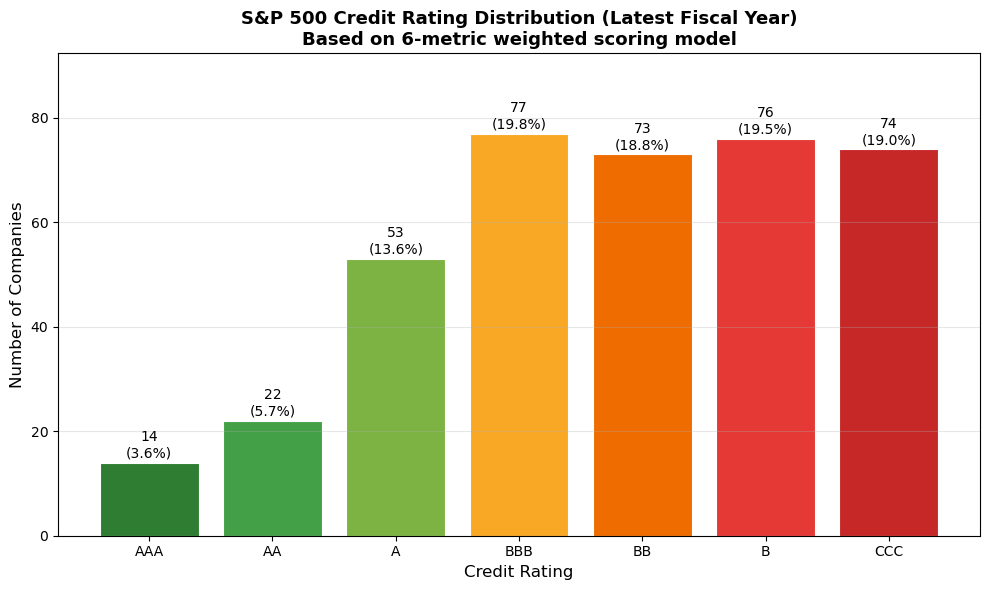

In [13]:
# --- Chart 1: Rating Distribution ---
latest        = df_scored.sort_values('fiscal_year').groupby('ticker').last().reset_index()
rating_counts = latest['rating'].value_counts().reindex(RATING_ORDER)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    RATING_ORDER,
    [rating_counts[r] for r in RATING_ORDER],
    color=[RATING_COLORS[r] for r in RATING_ORDER],
    edgecolor='white', linewidth=0.8
)
for bar, r in zip(bars, RATING_ORDER):
    count = rating_counts[r]
    pct   = count / len(latest) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{count}\n({pct:.1f}%)', ha='center', fontsize=10)

ax.set_title('S&P 500 Credit Rating Distribution (Latest Fiscal Year)\n'
             'Based on 6-metric weighted scoring model',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Credit Rating', fontsize=12)
ax.set_ylabel('Number of Companies', fontsize=12)
ax.set_ylim(0, rating_counts.max() * 1.2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/01_rating_distribution.png', dpi=150)
plt.show()

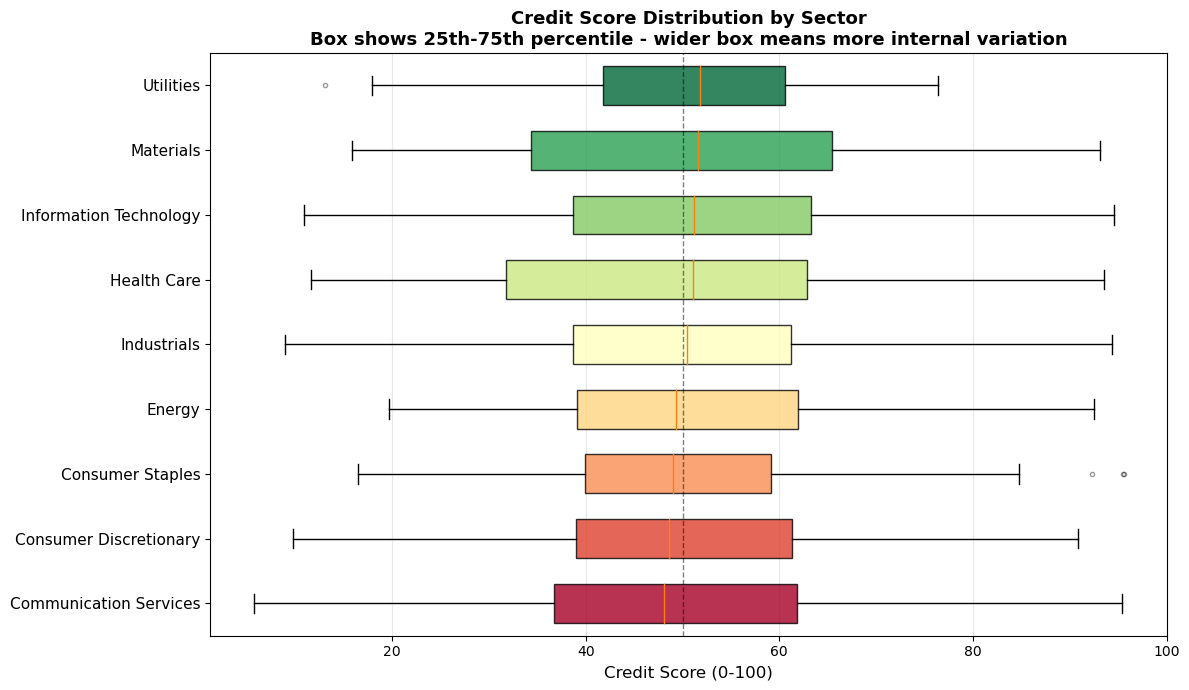

In [14]:
# --- Chart 2: Score Distribution by Sector (Box Plot) ---
# Box width and tail length reveal how much variance exists within each sector
sector_order = df_scored.groupby('sector')['credit_score']\
    .median().sort_values(ascending=True).index.tolist()

fig, ax = plt.subplots(figsize=(12, 7))
data_by_sector = [
    df_scored[df_scored['sector'] == s]['credit_score'].dropna()
    for s in sector_order
]
bp = ax.boxplot(data_by_sector, vert=False, patch_artist=True,
                widths=0.6, showfliers=True,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))

colors = plt.cm.RdYlGn([i / (len(sector_order) - 1) for i in range(len(sector_order))])
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_yticks(range(1, len(sector_order) + 1))
ax.set_yticklabels(sector_order, fontsize=11)
ax.axvline(50, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Credit Score (0-100)', fontsize=12)
ax.set_title('Credit Score Distribution by Sector\n'
             'Box shows 25th-75th percentile - wider box means more internal variation',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/02_sector_scores.png', dpi=150)
plt.show()

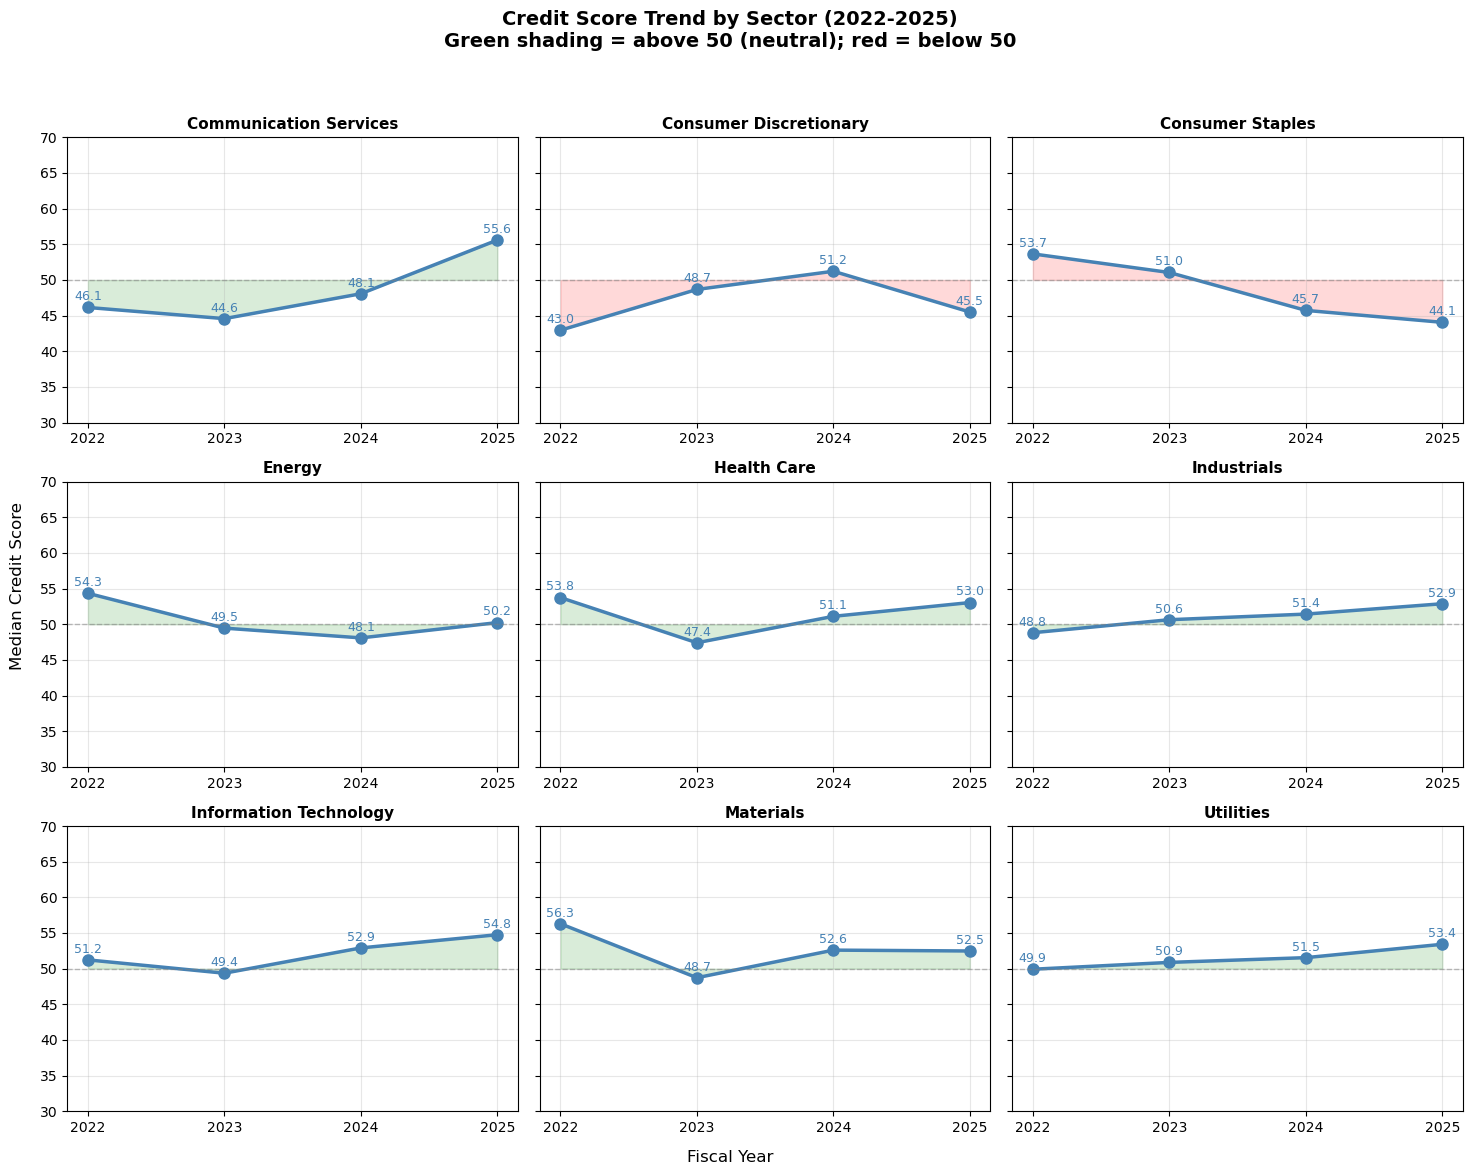

In [15]:
# --- Chart 3: Score Trend by Sector (Facet Grid) ---
# One subplot per sector makes it easier to read individual trends
trend = df_scored.groupby(['fiscal_year', 'sector'])['credit_score']\
    .median().reset_index()
trend = trend[trend['fiscal_year'].isin([2022, 2023, 2024, 2025])]

sectors = sorted(trend['sector'].unique())
n_cols  = 3
n_rows  = int(np.ceil(len(sectors) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12), sharey=True)
axes = axes.flatten()

for i, sector in enumerate(sectors):
    ax   = axes[i]
    data = trend[trend['sector'] == sector]
    last_score = data['credit_score'].iloc[-1]

    ax.plot(data['fiscal_year'], data['credit_score'],
            marker='o', linewidth=2.5, markersize=8, color='steelblue')
    ax.fill_between(data['fiscal_year'], data['credit_score'], 50,
                    alpha=0.15,
                    color='green' if last_score >= 50 else 'red')
    ax.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_title(sector, fontweight='bold', fontsize=11)
    ax.set_xticks([2022, 2023, 2024, 2025])
    ax.set_ylim(30, 70)
    ax.grid(alpha=0.3)

    for _, row in data.iterrows():
        ax.text(row['fiscal_year'], row['credit_score'] + 1,
                f"{row['credit_score']:.1f}",
                ha='center', fontsize=9, color='steelblue')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Credit Score Trend by Sector (2022-2025)\n'
             'Green shading = above 50 (neutral); red = below 50',
             fontsize=14, fontweight='bold')
fig.text(0.5, 0.02, 'Fiscal Year', ha='center', fontsize=12)
fig.text(0.02, 0.5, 'Median Credit Score', va='center',
         rotation='vertical', fontsize=12)
plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
plt.savefig('outputs/03_score_trend.png', dpi=150, bbox_inches='tight')
plt.show()

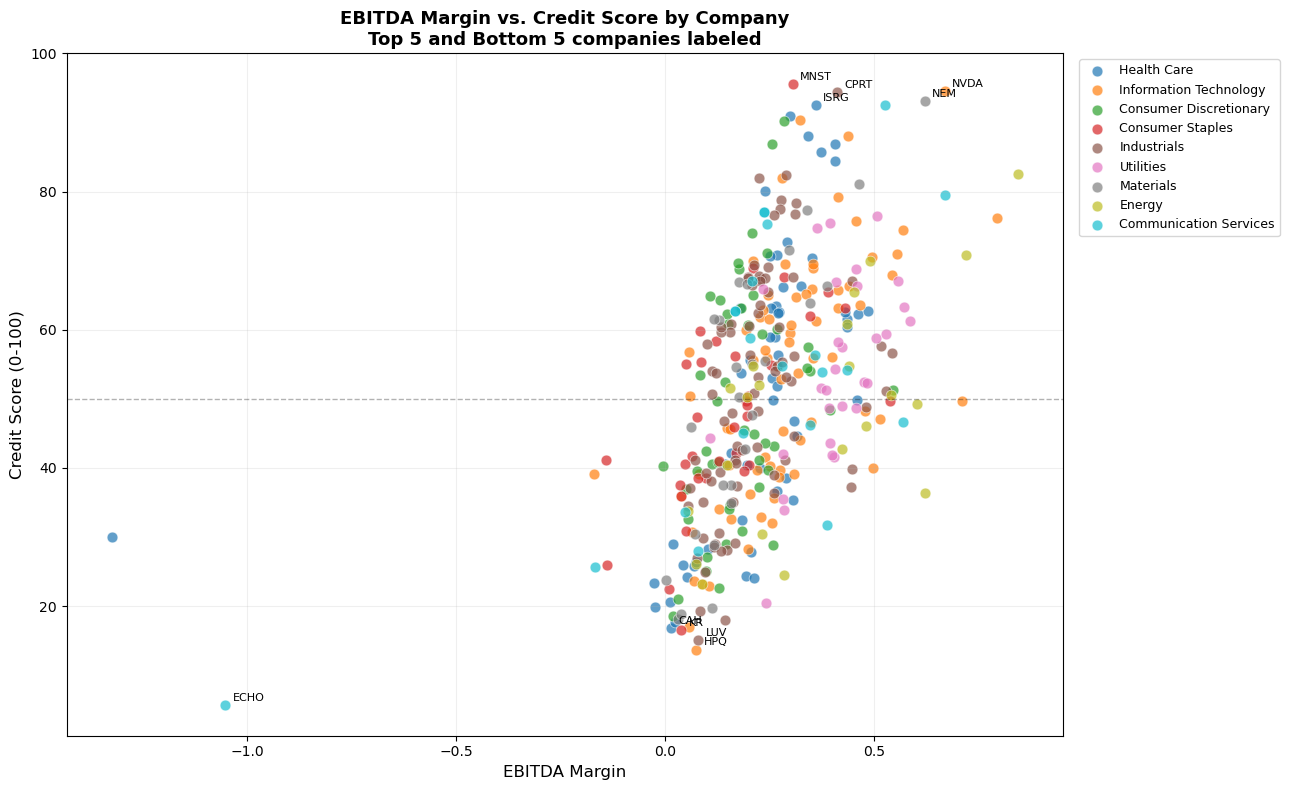

In [18]:
# --- Chart 4: EBITDA Margin vs Credit Score Scatter ---
latest_full = df_scored.sort_values('fiscal_year').groupby('ticker').last().reset_index()

# ebitda_margin is already in df_scored - no merge needed
# Rename if it shows as ebitda_margin_x
if 'ebitda_margin_x' in latest_full.columns:
    latest_full = latest_full.rename(columns={'ebitda_margin_x': 'ebitda_margin'})

sectors      = latest_full['sector'].unique()
sector_color = dict(zip(sectors, plt.cm.tab10(np.linspace(0, 1, len(sectors)))))

fig, ax = plt.subplots(figsize=(13, 8))
for sector in sectors:
    data = latest_full[latest_full['sector'] == sector]
    ax.scatter(data['ebitda_margin'], data['credit_score'],
               c=[sector_color[sector]], label=sector,
               s=60, alpha=0.7, edgecolors='white', linewidths=0.5)

top5    = latest_full.nlargest(5, 'credit_score')
bottom5 = latest_full.nsmallest(5, 'credit_score')
for _, row in pd.concat([top5, bottom5]).iterrows():
    ax.annotate(row['ticker'],
                xy=(row['ebitda_margin'], row['credit_score']),
                xytext=(5, 3), textcoords='offset points', fontsize=8)

ax.set_xlabel('EBITDA Margin', fontsize=12)
ax.set_ylabel('Credit Score (0-100)', fontsize=12)
ax.set_title('EBITDA Margin vs. Credit Score by Company\n'
             'Top 5 and Bottom 5 companies labeled',
             fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.axhline(50, color='black', linestyle='--', linewidth=1, alpha=0.3)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('outputs/04_company_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

Companies on risk watchlist: 76


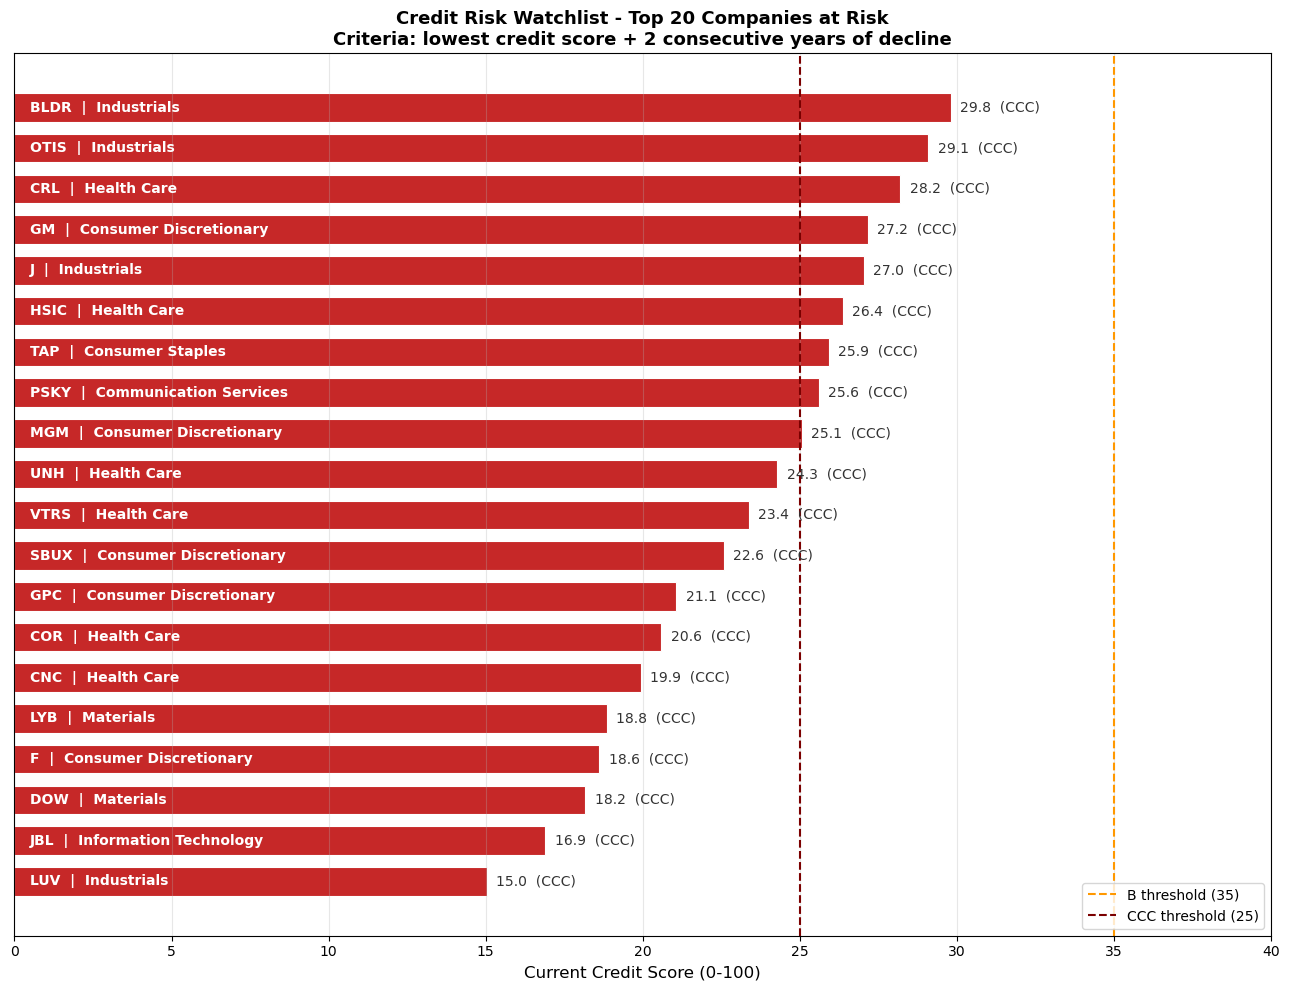

In [19]:
# --- Chart 5: Credit Risk Watchlist ---
# Identifies companies with both low current scores AND declining trends
# Criteria: 2+ consecutive years of declining credit score

df_trend = df_scored.sort_values(['ticker', 'fiscal_year'])
df_trend['score_change'] = df_trend.groupby('ticker')['credit_score'].diff()

def is_declining(group):
    """Return True if last 2 year-over-year changes are both negative."""
    changes = group['score_change'].dropna()
    if len(changes) < 2:
        return False
    return all(changes.tail(2) < 0)

declining        = df_trend.groupby('ticker').filter(is_declining)
declining_latest = declining.sort_values('fiscal_year')\
    .groupby('ticker').last().reset_index()
declining_latest = declining_latest.sort_values('credit_score')

print(f'Companies on risk watchlist: {len(declining_latest)}')

top20_risk = declining_latest.head(20)
colors     = [RATING_COLORS[r] for r in top20_risk['rating']]

fig, ax = plt.subplots(figsize=(13, 10))
bars = ax.barh(range(len(top20_risk)), top20_risk['credit_score'],
               color=colors, edgecolor='white', linewidth=0.8, height=0.7)

for i, (_, row) in enumerate(top20_risk.iterrows()):
    ax.text(0.5, i, f"{row['ticker']}  |  {row['sector']}",
            va='center', fontsize=10, fontweight='bold', color='white')
    ax.text(row['credit_score'] + 0.3, i,
            f"{row['credit_score']:.1f}  ({row['rating']})",
            va='center', fontsize=10, color='#333333')

ax.set_yticks([])
ax.set_xlabel('Current Credit Score (0-100)', fontsize=12)
ax.set_title('Credit Risk Watchlist - Top 20 Companies at Risk\n'
             'Criteria: lowest credit score + 2 consecutive years of decline',
             fontsize=13, fontweight='bold')
ax.axvline(35, color='#ff9800', linestyle='--', linewidth=1.5, label='B threshold (35)')
ax.axvline(25, color='#7b0000', linestyle='--', linewidth=1.5, label='CCC threshold (25)')
ax.set_xlim(0, 40)
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/05_risk_watchlist.png', dpi=150)
plt.show()

---
## 9. Key Findings

| Finding | Value |
|---|---|
| Companies analyzed | 389 across 9 sectors |
| Fiscal years covered | 2022 - 2025 |
| Companies rated AAA or AA | 36 (9.3%) |
| Companies on risk watchlist | 76 |
| Sectors improving (2022-2025) | Communication Services, Information Technology |
| Sectors declining (2022-2025) | Consumer Staples, Consumer Discretionary |

**Risk signals that align with market reality:**
- **SBUX** (score 22.6): 3 consecutive years of decline - same-store sales dropped significantly 2023-2025
- **UNH** (score 24.3): rising medical loss ratios and regulatory pressure throughout 2024-2025
- **F** (score 18.6): EV transition losses and margin compression

**Known model limitations:**
- Weights are judgment-based, not statistically derived from default data
- Negative equity companies may be over-penalized (e.g. OTIS has strong cash flows despite negative book equity from buybacks)
- Interest expense imputation assumes stable debt structure

**Future improvements:**
- Use logistic regression on historical default data to derive data-driven weights
- Add sector-specific metrics (same-store sales for retail, etc.)
- Validate against CDS spreads as an external benchmark